In [1]:
!pip install --upgrade pip
!pip install pandas
!pip install seaborn
!pip install scipy

Let me help you import seaborn.

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
pyafar_adu_filename = "/datasets/_deepnote_work/pyafar_adults.csv"
pyafar_inf_filename = "/datasets/_deepnote_work/pyafar_infants.csv"
# Load csv files into Pandas DataFrames
pyafar_inf_df = pd.read_csv(pyafar_inf_filename)
pyafar_adu_df = pd.read_csv(pyafar_adu_filename)

In [4]:
affect_map = {3: "Pos", 1: "Neg", 2: "Neu"}
au_columns_inf = ['AU1', 'AU2', 'AU3', 'AU4', 'AU6', 'AU9', 'AU12', 'AU20', 'AU28']
au_columns_adu = ['AU1', 'AU2', 'AU4', 'AU6', 'AU7', 'AU10', 'AU12', 'AU14', 'AU15', 'AU17', 'AU23', 'AU24']
custom_palette = {3: "#2ca02c", 1: "#d62728", 2: "#7f7f7f"}
custom_palette_string = { "3": "#2ca02c", "1": "#d62728", "2": "#7f7f7f"}

In [5]:
# Drop rows with NaN values in the 'imageCat' column
pyafar_inf_df = pyafar_inf_df.dropna(subset=["imageCat"])
pyafar_adu_df = pyafar_adu_df.dropna(subset=["imageCat"])
pyafar_inf_df["imageCat"] = pyafar_inf_df["imageCat"].astype(int)
pyafar_adu_df["imageCat"] = pyafar_adu_df["imageCat"].astype(int)

# For infants df, check if 'Image' exists
if 'Image' in pyafar_inf_df.columns:
    # Select relevant columns for infants
    au_columns_inf = ['Occ_au_1', 'Occ_au_2', 'Occ_au_3', 'Occ_au_4', 'Occ_au_6', 'Occ_au_9', 'Occ_au_12', 'Occ_au_20', 'Occ_au_28']
    pyafar_inf_df = pyafar_inf_df[['imageID', 'Image'] + au_columns_inf + ['imageCat']]
    pyafar_inf_df["imageCat"] = pyafar_inf_df["imageCat"].astype(int)

    # Rename the action units columns for infants
    pyafar_inf_df = pyafar_inf_df.rename(columns={col: f"AU{col.split('_')[-1]}" for col in au_columns_inf})
    pyafar_inf_df = pyafar_inf_df[['imageID', 'Image'] + [f"AU{col.split('_')[-1]}" for col in au_columns_inf] + ['imageCat']]
else:
    print("'Image' column not found in infant dataset")

# For adults df, check if 'Image' exists
if 'Image' in pyafar_adu_df.columns:
    # Select relevant columns for adults
    au_columns_adu = ['Occ_au_1', 'Occ_au_2', 'Occ_au_4', 'Occ_au_6', 'Occ_au_7', 'Occ_au_10', 'Occ_au_12', 'Occ_au_14', 'Occ_au_15', 'Occ_au_17', 'Occ_au_23', 'Occ_au_24']
    pyafar_adu_df = pyafar_adu_df[['imageID', 'Image'] + au_columns_adu + ['imageCat']]
    pyafar_adu_df["imageCat"] = pyafar_adu_df["imageCat"].astype(int)

    # Rename the action units columns for adults
    pyafar_adu_df = pyafar_adu_df.rename(columns={col: f"AU{col.split('_')[-1]}" for col in au_columns_adu})
    pyafar_adu_df = pyafar_adu_df[['imageID', 'Image'] + [f"AU{col.split('_')[-1]}" for col in au_columns_adu] + ['imageCat']]
else:
    print("'Image' column not found in adult dataset")

/tmp/ipykernel_280/4195711299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_inf = sns.countplot(x="imageCat", data=pyafar_inf_df, palette=custom_palette_string)
/tmp/ipykernel_280/4195711299.py:4: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_inf.set_xticklabels([affect_map[label] for label in sorted(pyafar_inf_df["imageCat"].unique())])


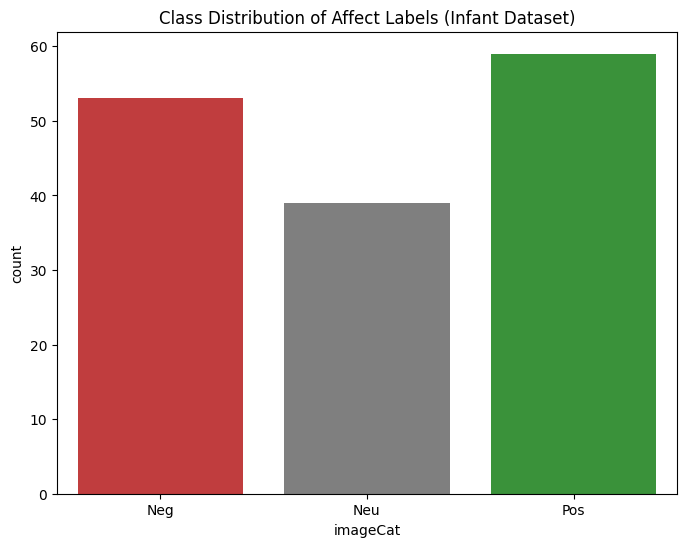

In [6]:
# Affect distribution for infant dataset
plt.figure(figsize=(8, 6))
ax_inf = sns.countplot(x="imageCat", data=pyafar_inf_df, palette=custom_palette_string)
ax_inf.set_xticklabels([affect_map[label] for label in sorted(pyafar_inf_df["imageCat"].unique())])
plt.title("Class Distribution of Affect Labels (Infant Dataset)")
plt.show()

In [7]:
# List of action units for both datasets
au_columns_inf = ['AU1', 'AU2', 'AU3', 'AU4', 'AU6', 'AU9', 'AU12', 'AU20', 'AU28']
au_columns_adu = ['AU1', 'AU2', 'AU4', 'AU6', 'AU7', 'AU10', 'AU12', 'AU14', 'AU15', 'AU17', 'AU23', 'AU24']


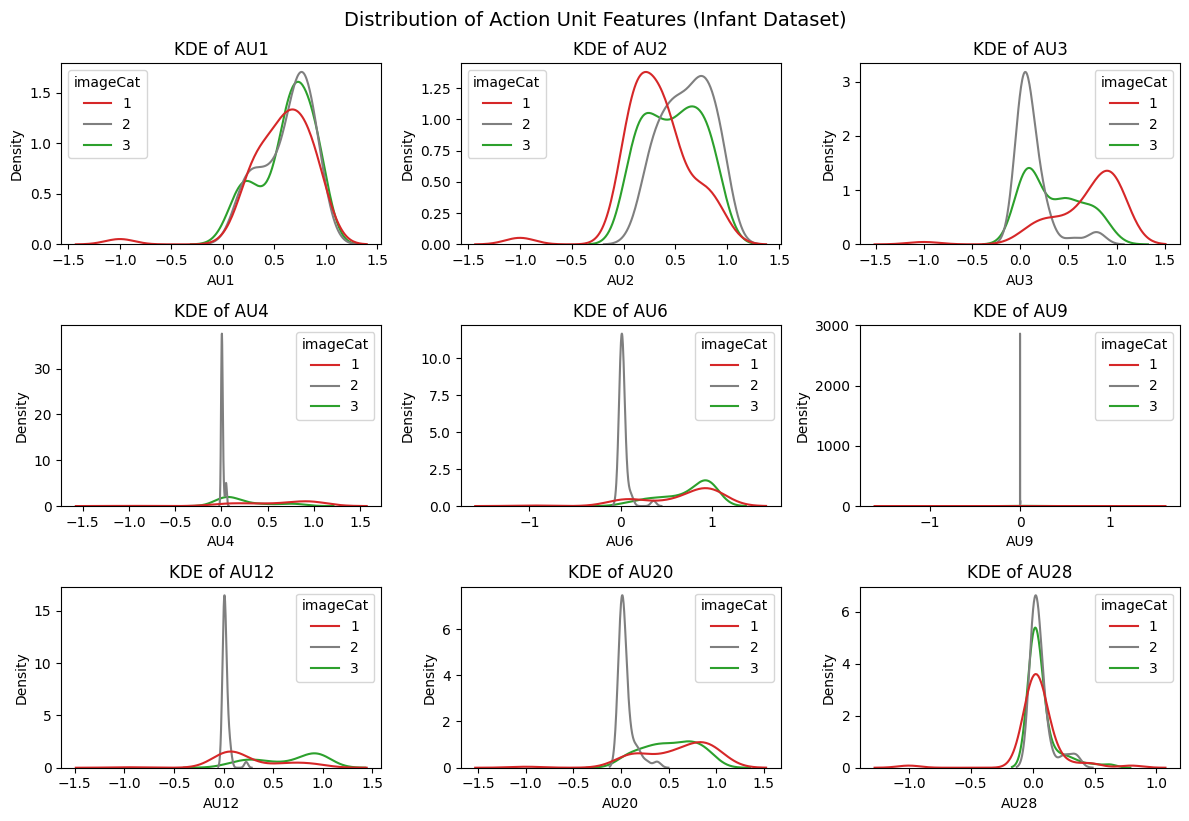

In [8]:
# Distribution of AUs for Inf
# Plot for Infant dataset
plt.figure(figsize=(12, 8))
for i, au in enumerate(au_columns_inf, 1):
    plt.subplot(3, 3, i)  # Arrange the plots in a 3x3 grid
    sns.kdeplot(data=pyafar_inf_df, x=au, hue="imageCat", fill=False, common_norm=False, palette=custom_palette)
    plt.title(f"KDE of {au}")
    plt.xlabel(f"{au}")
    plt.ylabel("Density")

plt.tight_layout()
plt.suptitle("Distribution of Action Unit Features (Infant Dataset)", fontsize=14, y=1.02)
plt.show()

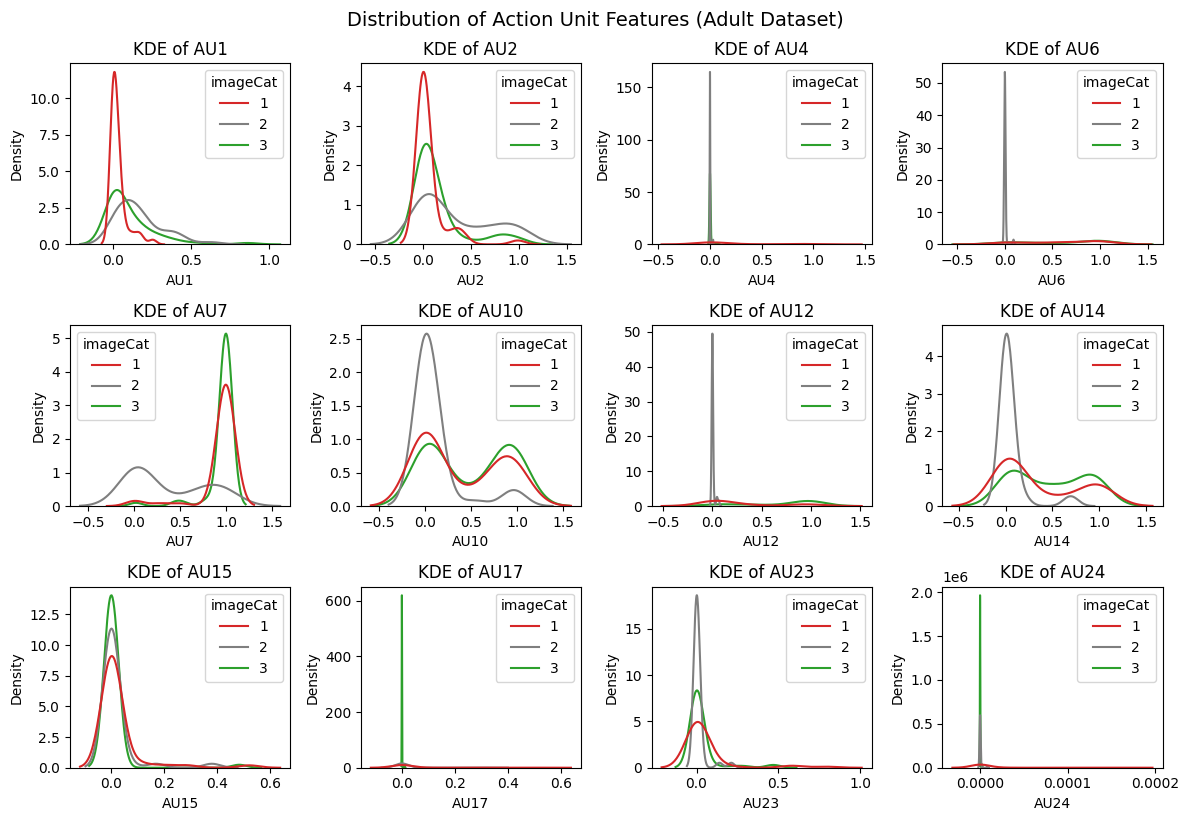

In [9]:
pyafar_adu_df[au_columns_adu] = pyafar_adu_df[au_columns_adu].apply(pd.to_numeric, errors='coerce')
# Distribution of AUs for Adu
# Plot for Adult dataset
plt.figure(figsize=(12, 8))
for i, au in enumerate(au_columns_adu, 1):
    plt.subplot(3, 4, i)  # Arrange the plots in a 3x4 grid for 12 action units
    sns.kdeplot(data=pyafar_adu_df, x=au, hue="imageCat", fill=False, common_norm=False, palette=custom_palette)
    plt.title(f"KDE of {au}")
    plt.xlabel(f"{au}")
    plt.ylabel("Density")

plt.tight_layout()
plt.suptitle("Distribution of Action Unit Features (Adult Dataset)", fontsize=14, y=1.02)
plt.show()

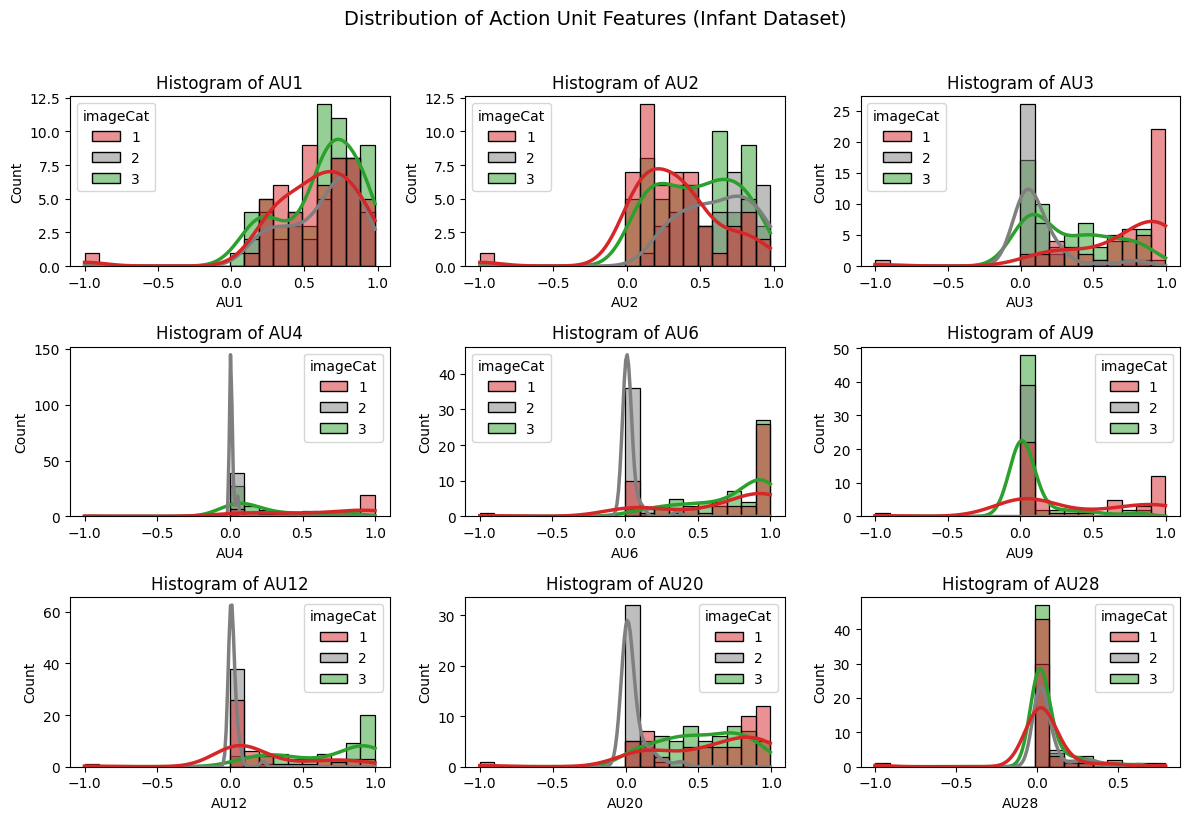

In [10]:
# Histogram Plot for Inf
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
fig.suptitle("Distribution of Action Unit Features (Infant Dataset)", fontsize=14, y=1.02)

for i, au in enumerate(au_columns_inf):
    row, col = divmod(i, 3)
    sns.histplot(data=pyafar_inf_df, x=au, hue="imageCat", kde=True, bins=20, palette=custom_palette, ax=axes[row, col])
    axes[row, col].set_title(f"Histogram of {au}")
    for line in axes[row, col].lines:
        line.set_linewidth(2.5)

plt.tight_layout()
plt.show()

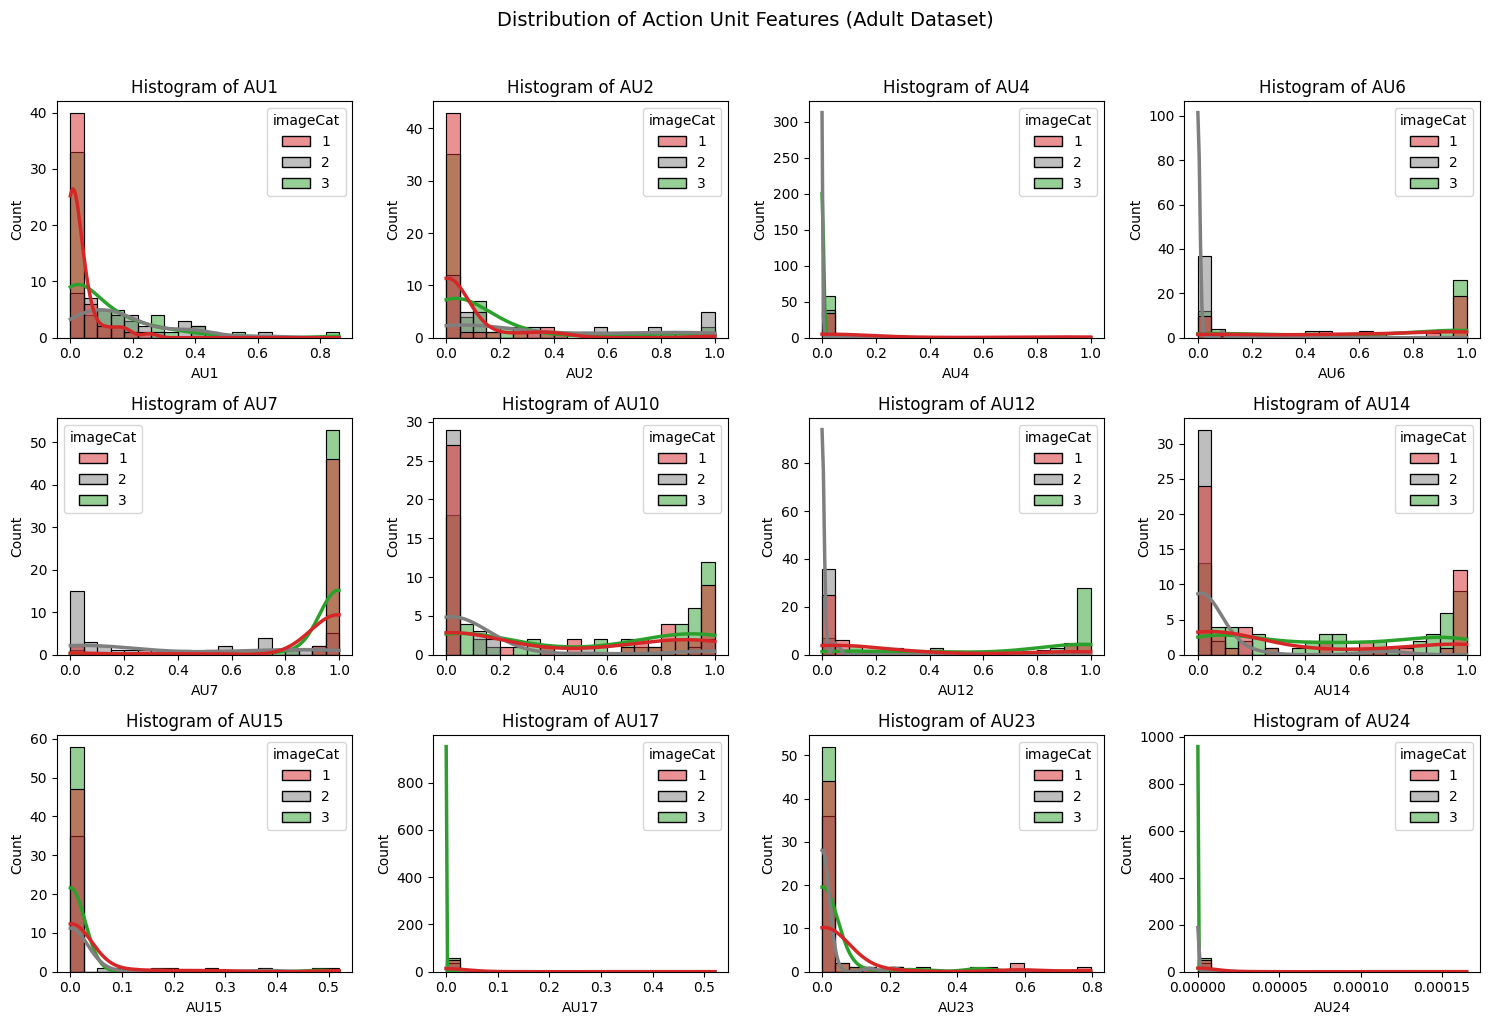

In [11]:
# Histogram Plot for Adult
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
fig.suptitle("Distribution of Action Unit Features (Adult Dataset)", fontsize=14, y=1.02)

for i, au in enumerate(au_columns_adu):
    row, col = divmod(i, 4)
    sns.histplot(data=pyafar_adu_df, x=au, hue="imageCat", kde=True, bins=20, palette=custom_palette, ax=axes[row, col])
    axes[row, col].set_title(f"Histogram of {au}")
    for line in axes[row, col].lines:
        line.set_linewidth(2.5)

plt.tight_layout()
plt.show()

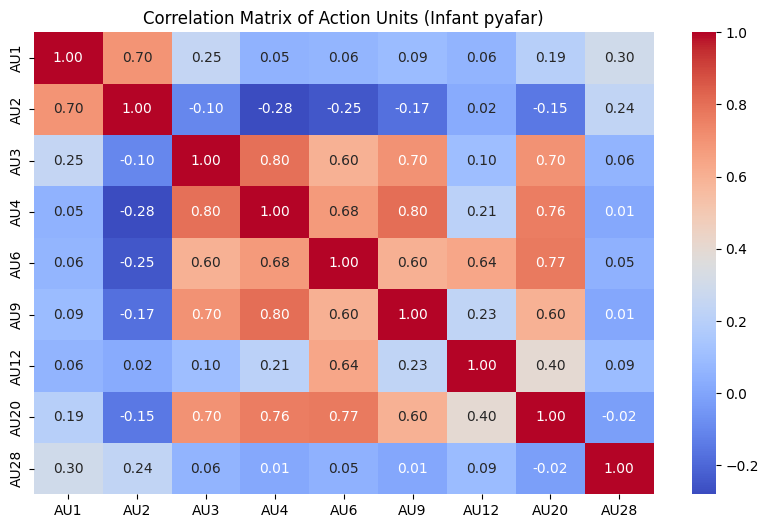

In [12]:
# Feature Correlation for Infant dataset
plt.figure(figsize=(10, 6))
sns.heatmap(pyafar_inf_df.iloc[:, 2:-1].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Action Units (Infant pyafar)")
plt.show()


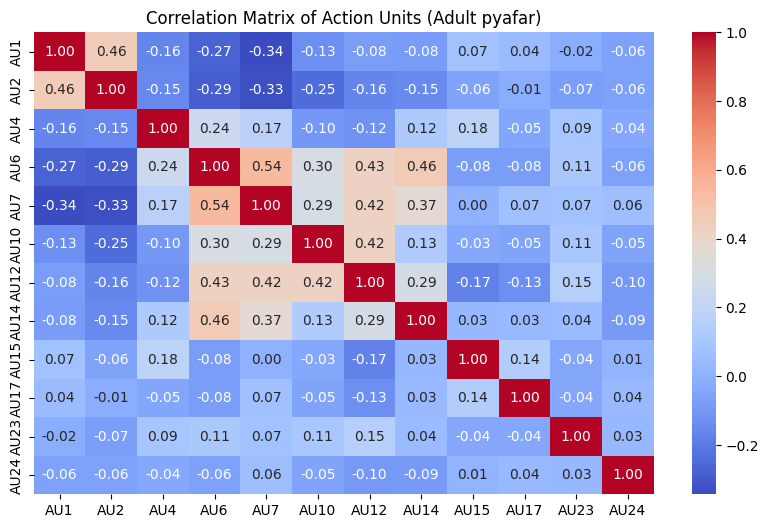

In [13]:
# Feature Correlation for Adult pyafar
plt.figure(figsize=(10, 6))
sns.heatmap(pyafar_adu_df.iloc[:, 2:-1].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Action Units (Adult pyafar)")
plt.show()

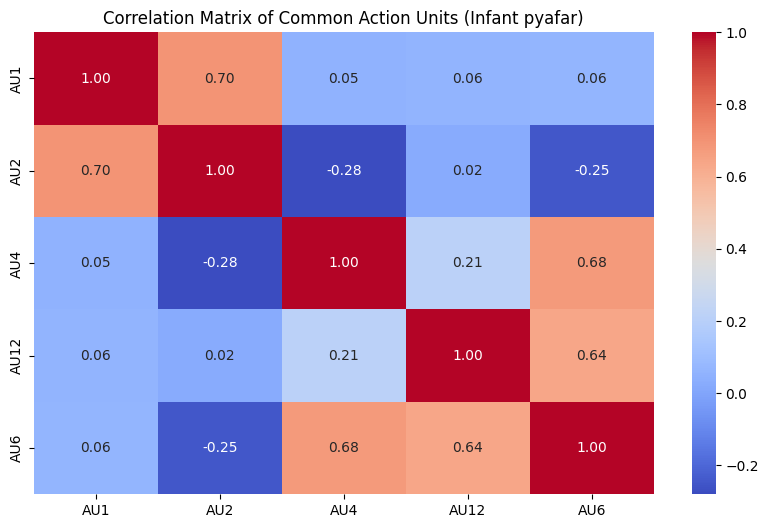

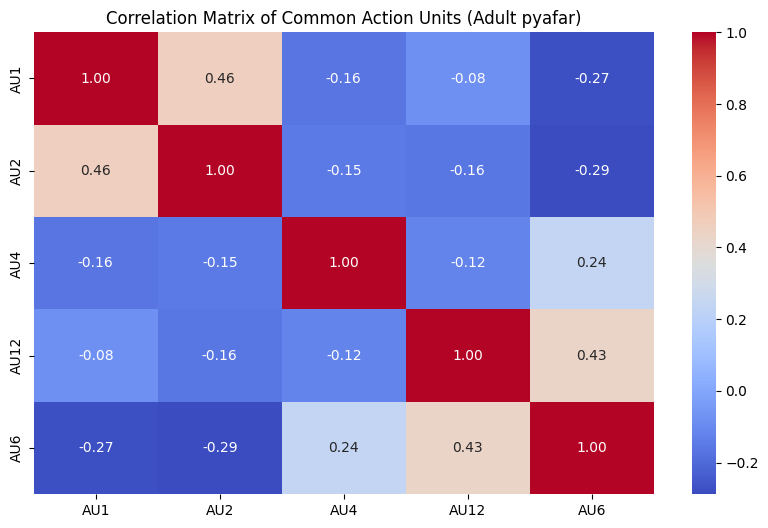

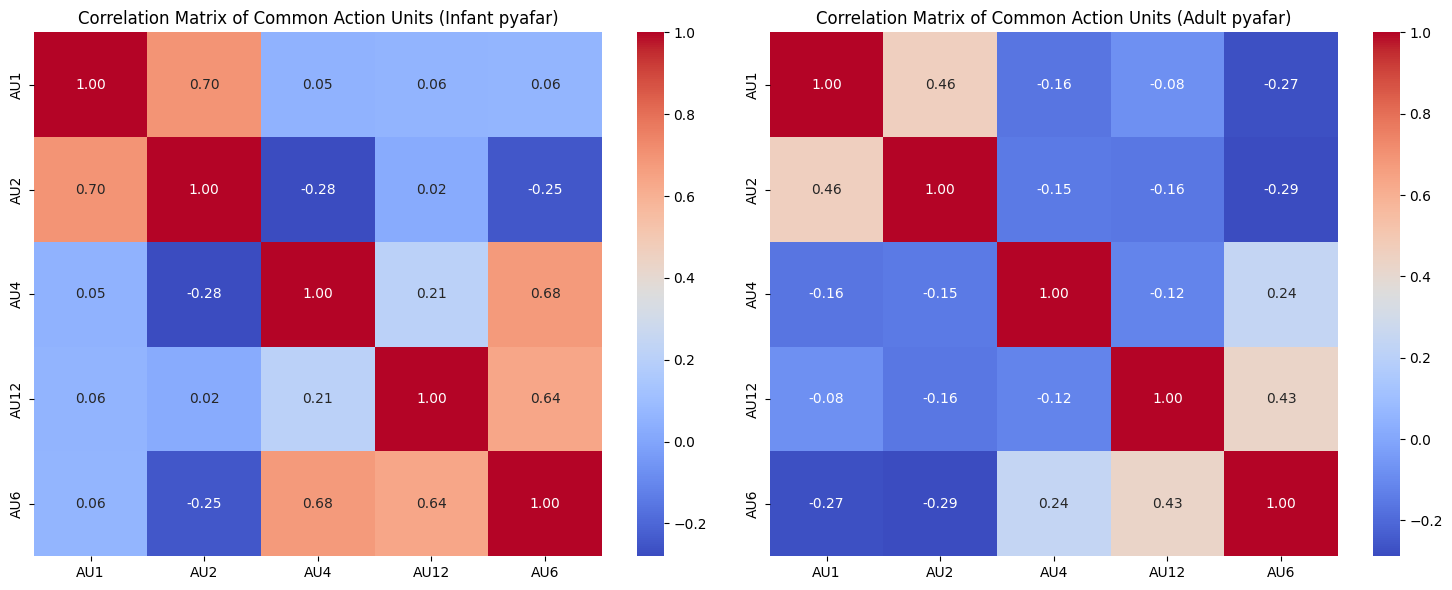

In [14]:
# Identify common action units (AUs) between infant and adult datasets
common_au_columns = ['AU1', 'AU2', 'AU4', 'AU12', 'AU6']

# Feature Correlation for Infant pyafar (common AUs)
plt.figure(figsize=(10, 6))
sns.heatmap(pyafar_inf_df[common_au_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Common Action Units (Infant pyafar)")
plt.show()

# Feature Correlation for Adult pyafar (common AUs)
plt.figure(figsize=(10, 6))
sns.heatmap(pyafar_adu_df[common_au_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Common Action Units (Adult pyafar)")
plt.show()

# Feature Correlation Comparison between Infant and Adult pyafar models (common AUs)
# Compute correlation matrices for both
df_pyafar_inf_corr = pyafar_inf_df[common_au_columns].corr()
df_pyafar_adu_corr = pyafar_adu_df[common_au_columns].corr()

# Create subplots for comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for Infant pyafar correlation
sns.heatmap(df_pyafar_inf_corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0])
axes[0].set_title("Correlation Matrix of Common Action Units (Infant pyafar)")

# Plot for Adult pyafar correlation
sns.heatmap(df_pyafar_adu_corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
axes[1].set_title("Correlation Matrix of Common Action Units (Adult pyafar)")

# Adult model shows less strength in correlations

plt.tight_layout()
plt.show()


In [15]:
# Function to calculate point-biserial correlations for AUs and affect labels
def compute_correlations(df, au_columns, affect_column):
    # Remove rows with NaN or infinite values in the AUs or affect column
    df_clean = df.dropna(subset=au_columns + [affect_column])
    df_clean = df_clean[~df_clean[au_columns].isin([float('inf'), float('-inf')]).any(axis=1)]
    
    # Create binary labels for affect categories
    df_clean['Pos_label'] = (df_clean[affect_column] == 3).astype(int)
    df_clean['Neu_label'] = (df_clean[affect_column] == 2).astype(int)
    df_clean['Neg_label'] = (df_clean[affect_column] == 1).astype(int)
    
    correlations = {}
    for au in au_columns:
        pos_corr, _ = stats.pointbiserialr(df_clean[au], df_clean['Pos_label'])
        neu_corr, _ = stats.pointbiserialr(df_clean[au], df_clean['Neu_label'])
        neg_corr, _ = stats.pointbiserialr(df_clean[au], df_clean['Neg_label'])
        
        correlations[au] = {'Pos': pos_corr, 'Neu': neu_corr, 'Neg': neg_corr}

    return pd.DataFrame(correlations).T

# Compute correlations for infant pyafar model
corr_inf_df = compute_correlations(pyafar_inf_df, au_columns_inf, 'imageCat')

# Compute correlations for adult pyafar model
corr_adu_df = compute_correlations(pyafar_adu_df, au_columns_adu, 'imageCat')

# Display the correlation dataframes for infant and adult
corr_inf_df, corr_adu_df


(           Pos       Neu       Neg
 AU1   0.050450  0.040363 -0.088588
 AU2   0.054905  0.297901 -0.329317
 AU3  -0.127219 -0.445249  0.538366
 AU4  -0.128615 -0.457473  0.551004
 AU6   0.391003 -0.677298  0.221399
 AU9  -0.191720 -0.296828  0.468195
 AU12  0.620963 -0.490126 -0.185329
 AU20  0.228016 -0.595446  0.312955
 AU28  0.060727  0.000459 -0.062500,
            Pos       Neu       Neg
 AU1   0.058849  0.302476 -0.336983
 AU2  -0.051172  0.344972 -0.262960
 AU4  -0.244473 -0.182558  0.417778
 AU6   0.299253 -0.602193  0.243640
 AU7   0.354369 -0.699938  0.276474
 AU10  0.249179 -0.343463  0.058420
 AU12  0.611969 -0.503841 -0.167154
 AU14  0.319582 -0.406274  0.043622
 AU15 -0.088781  0.002680  0.088641
 AU17 -0.122877 -0.002472  0.128335
 AU23 -0.021887 -0.111210  0.124154
 AU24 -0.090817 -0.059171  0.147290)

In [16]:
# Merge the correlation dataframes for comparison
comparison_df = pd.merge(corr_inf_df, corr_adu_df, left_index=True, right_index=True, suffixes=('_inf', '_adu'))

# Calculate the difference and percentage change for each AU
comparison_df['Diff_Pos'] = comparison_df['Pos_inf'] - comparison_df['Pos_adu']
comparison_df['Diff_Neu'] = comparison_df['Neu_inf'] - comparison_df['Neu_adu']
comparison_df['Diff_Neg'] = comparison_df['Neg_inf'] - comparison_df['Neg_adu']

# Calculate percentage change
comparison_df['Pct_Change_Pos'] = ((comparison_df['Pos_adu'] - comparison_df['Pos_inf']) / comparison_df['Pos_inf']) * 100
comparison_df['Pct_Change_Neu'] = ((comparison_df['Neu_adu'] - comparison_df['Neu_inf']) / comparison_df['Neu_inf']) * 100
comparison_df['Pct_Change_Neg'] = ((comparison_df['Neg_adu'] - comparison_df['Neg_inf']) / comparison_df['Neg_inf']) * 100

# Display the comparison dataframe
comparison_df


,Pos_inf,Neu_inf,Neg_inf,Pos_adu,Neu_adu,Neg_adu,Diff_Pos,Diff_Neu,Diff_Neg,Pct_Change_Pos,Pct_Change_Neu,Pct_Change_Neg
AU1,0.050450,0.040363,-0.088588,0.058849,0.302476,-0.336983,-0.008399,-0.262113,0.248395,16.648928,649.393846,280.394309
AU2,0.054905,0.297901,-0.329317,-0.051172,0.344972,-0.262960,0.106076,-0.047070,-0.066357,-193.200842,15.800660,-20.149841
AU4,-0.128615,-0.457473,0.551004,-0.244473,-0.182558,0.417778,0.115857,-0.274916,0.133226,90.080494,-60.094318,-24.178695
AU6,0.391003,-0.677298,0.221399,0.299253,-0.602193,0.243640,0.091750,-0.075105,-0.022241,-23.465224,-11.088960,10.045727
AU12,0.620963,-0.490126,-0.185329,0.611969,-0.503841,-0.167154,0.008994,0.013715,-0.018175,-1.448354,2.798305,-9.806788


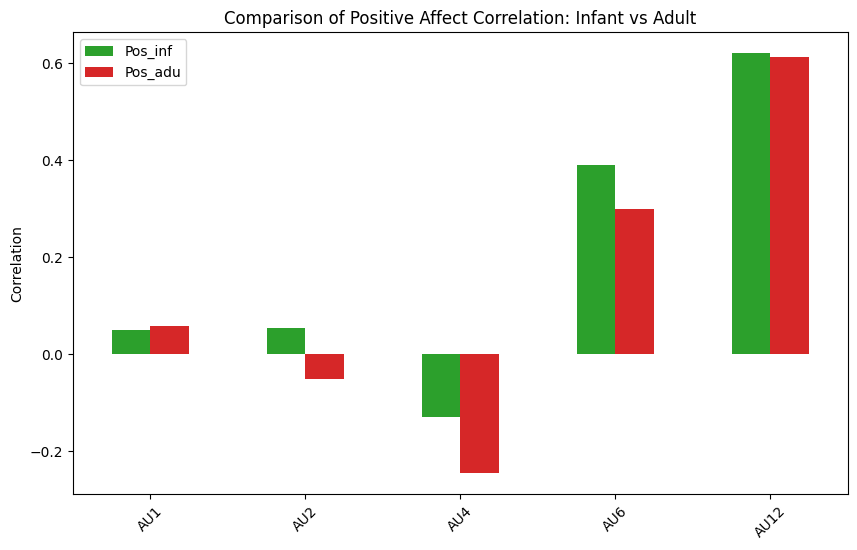

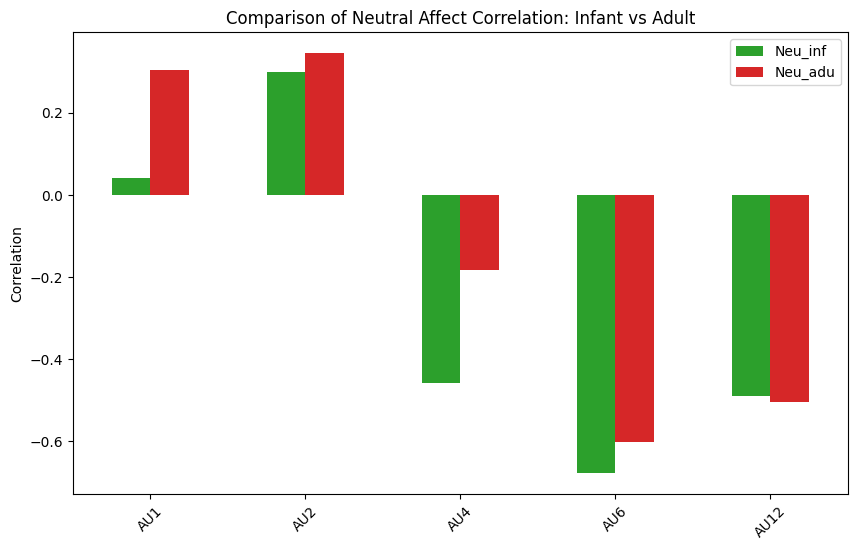

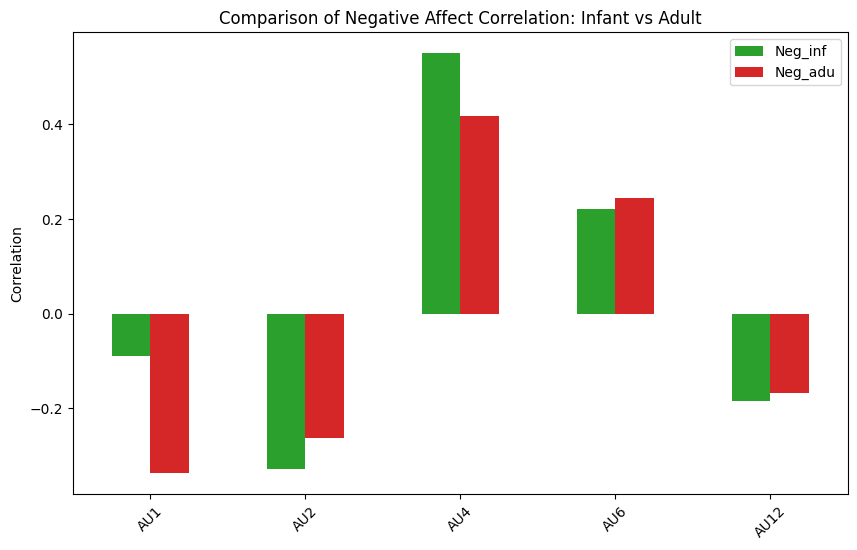

In [17]:
# Bar plots to compare the correlations between the infant and adult datasets
comparison_df[['Pos_inf', 'Pos_adu']].plot(kind='bar', figsize=(10, 6), color=['#2ca02c', '#d62728'])
plt.title("Comparison of Positive Affect Correlation: Infant vs Adult")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.show()

comparison_df[['Neu_inf', 'Neu_adu']].plot(kind='bar', figsize=(10, 6), color=['#2ca02c', '#d62728'])
plt.title("Comparison of Neutral Affect Correlation: Infant vs Adult")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.show()

comparison_df[['Neg_inf', 'Neg_adu']].plot(kind='bar', figsize=(10, 6), color=['#2ca02c', '#d62728'])
plt.title("Comparison of Negative Affect Correlation: Infant vs Adult")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.show()


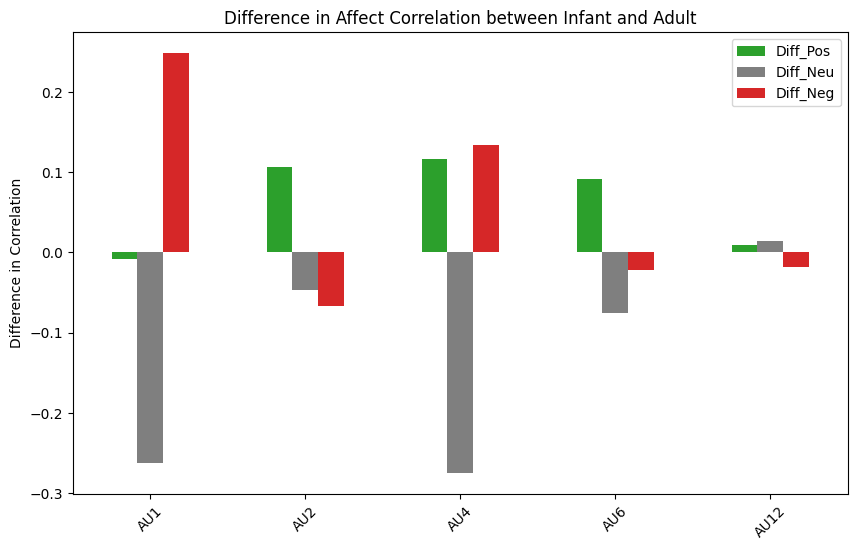

In [18]:
comparison_df[['Diff_Pos', 'Diff_Neu', 'Diff_Neg']].plot(kind='bar', figsize=(10, 6), color=['#2ca02c', '#7f7f7f', '#d62728'])
plt.title("Difference in Affect Correlation between Infant and Adult")
plt.ylabel("Difference in Correlation")
plt.xticks(rotation=45)
plt.show()

# Positive differences mean adult correlations are stronger while negative indicate infant correlations are stronger

In [19]:
# For Infant 
pyafar_inf_df['Pos_label'] = (pyafar_inf_df['imageCat'] == 3).astype(int)
pyafar_inf_df['Neu_label'] = (pyafar_inf_df['imageCat'] == 2).astype(int)
pyafar_inf_df['Neg_label'] = (pyafar_inf_df['imageCat'] == 1).astype(int)

# For Adult 
pyafar_adu_df['Pos_label'] = (pyafar_adu_df['imageCat'] == 3).astype(int)
pyafar_adu_df['Neu_label'] = (pyafar_adu_df['imageCat'] == 2).astype(int)
pyafar_adu_df['Neg_label'] = (pyafar_adu_df['imageCat'] == 1).astype(int)


In [20]:
# check df
pyafar_inf_df

,imageID,Image,AU1,AU2,AU3,AU4,AU6,AU9,AU12,AU20,AU28,imageCat,Pos_label,Neu_label,Neg_label
0,1,B1NegBW.bmp,0.582647,0.247536,0.199609,0.144951,0.749107,0.003546,0.262145,0.139866,0.054499,1,0,0,1
1,2,B1PosBw.bmp,0.630913,0.275316,0.029434,0.033410,0.921085,0.000916,0.968933,0.033123,0.257921,3,1,0,0
2,3,B2NegBw.bmp,0.501219,0.444231,0.948115,0.959741,0.999109,0.995002,0.920718,0.844951,0.002154,1,0,0,1
3,4,B2NeuBW.bmp,0.398275,0.739382,0.014437,0.011242,0.006104,0.000025,0.002992,0.002519,0.055800,2,0,1,0
4,6,B2PosBW.bmp,0.468657,0.641653,0.062889,0.042301,0.946381,0.005141,0.983136,0.750964,0.006738,3,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,255,G34NegBW.bmp,0.425449,0.031160,0.643459,0.670010,0.244077,0.003154,0.004786,0.854814,0.111297,1,0,0,1
147,256,G34NeuBW.bmp,0.710459,0.738828,0.097361,0.004639,0.006792,0.000014,0.002503,0.000683,0.341710,2,0,1,0
148,257,G34PosBW.bmp,0.753257,0.374755,0.552317,0.193810,0.768661,0.015868,0.505514,0.339446,0.054248,3,1,0,0
149,258,G35NegBW.bmp,0.554940,0.247877,0.963012,0.892812,0.988188,0.622714,0.599941,0.992239,0.011972,1,0,0,1


<Figure size 1200x600 with 0 Axes>

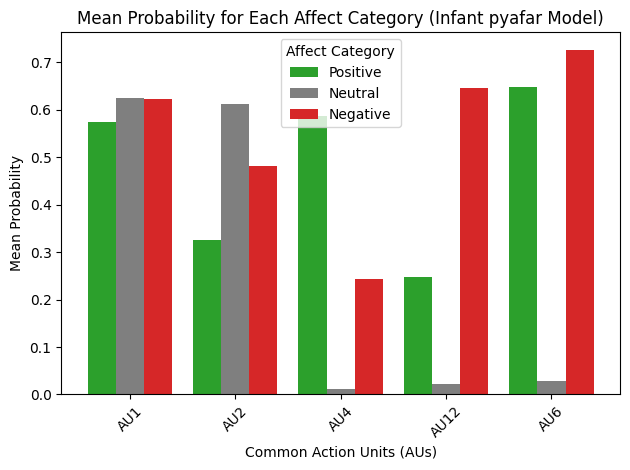

<Figure size 1200x600 with 0 Axes>

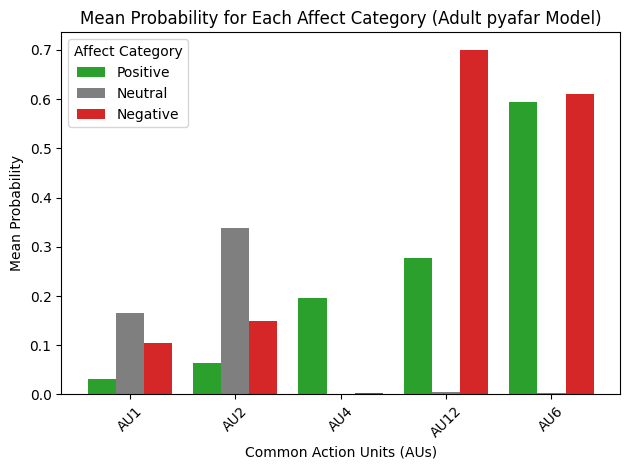

In [21]:
# Corrected palette: Positive is red, Negative is green, Neutral is gray
custom_palette_string = { "3": "#d62728", "1": "#2ca02c", "2": "#7f7f7f"}

# For Infant pyafar
mean_probs_inf = pyafar_inf_df.groupby('imageCat')[common_au_columns].mean()

# Plot the mean probabilities for each affect category for Infant pyafar
plt.figure(figsize=(12, 6))
mean_probs_inf.T.plot(kind='bar', stacked=False, width=0.8, color=[custom_palette_string[str(x)] for x in mean_probs_inf.index])
plt.title("Mean Probability for Each Affect Category (Infant pyafar Model)")
plt.ylabel("Mean Probability")
plt.xlabel("Common Action Units (AUs)")
plt.xticks(rotation=45)
plt.legend(title="Affect Category", labels=["Positive", "Neutral", "Negative"])
plt.tight_layout()
plt.show()

# For Adult pyafar
mean_probs_adu = pyafar_adu_df.groupby('imageCat')[common_au_columns].mean()

# Plot the mean probabilities for each affect category for Adult pyafar
plt.figure(figsize=(12, 6))
mean_probs_adu.T.plot(kind='bar', stacked=False, width=0.8, color=[custom_palette_string[str(x)] for x in mean_probs_adu.index])
plt.title("Mean Probability for Each Affect Category (Adult pyafar Model)")
plt.ylabel("Mean Probability")
plt.xlabel("Common Action Units (AUs)")
plt.xticks(rotation=45)
plt.legend(title="Affect Category", labels=["Positive", "Neutral", "Negative"])
plt.tight_layout()
plt.show()


/tmp/ipykernel_280/4015213416.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AU', y='Mean Diff (Pos)', data=mean_diff_df, palette='coolwarm', label='Positive Affect')


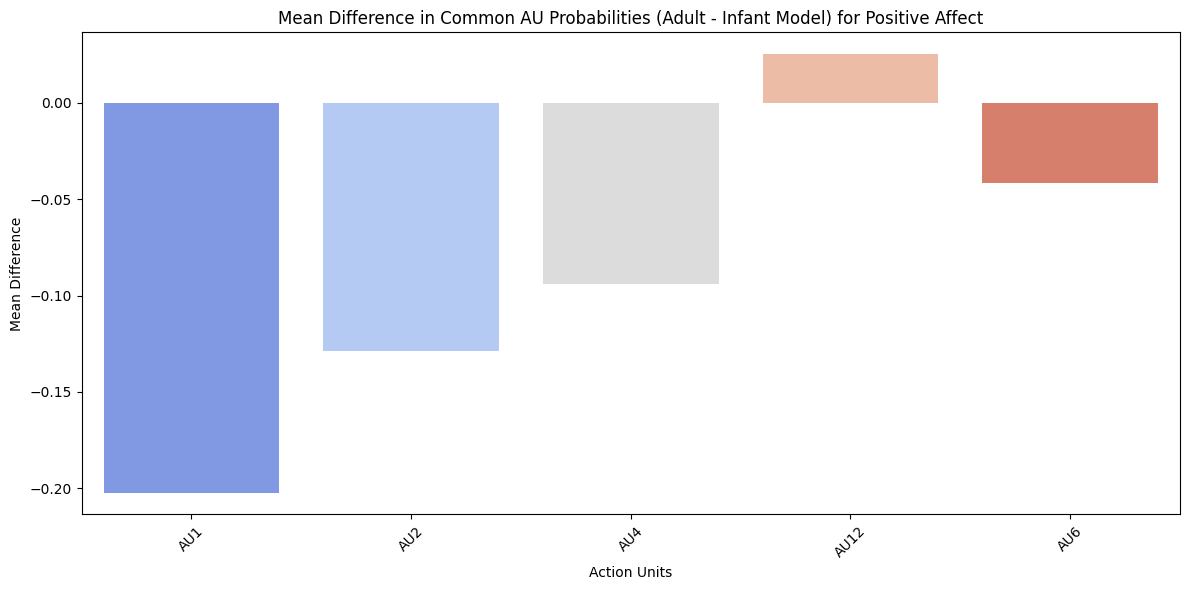

/tmp/ipykernel_280/4015213416.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AU', y='Mean Diff (Neu)', data=mean_diff_df, palette='coolwarm', label='Neutral Affect')


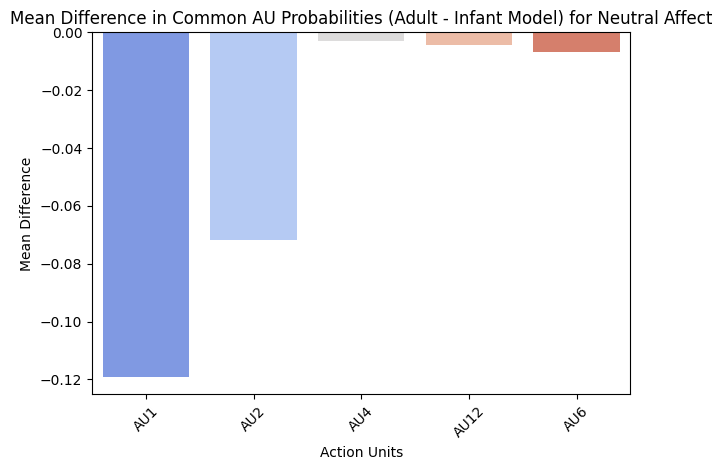

/tmp/ipykernel_280/4015213416.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AU', y='Mean Diff (Neg)', data=mean_diff_df, palette='coolwarm', label='Negative Affect')


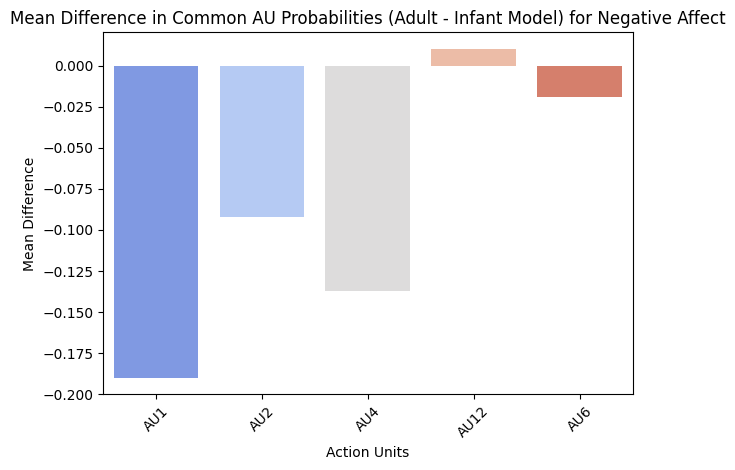

In [22]:
# Calculate mean probability for each AU and affect for both models (Infant and Adult)
mean_probs_inf_pos = pyafar_inf_df[common_au_columns].apply(lambda x: (x * pyafar_inf_df['Pos_label']).mean(), axis=0)
mean_probs_adu_pos = pyafar_adu_df[common_au_columns].apply(lambda x: (x * pyafar_adu_df['Pos_label']).mean(), axis=0)

mean_probs_inf_neu = pyafar_inf_df[common_au_columns].apply(lambda x: (x * pyafar_inf_df['Neu_label']).mean(), axis=0)
mean_probs_adu_neu = pyafar_adu_df[common_au_columns].apply(lambda x: (x * pyafar_adu_df['Neu_label']).mean(), axis=0)

mean_probs_inf_neg = pyafar_inf_df[common_au_columns].apply(lambda x: (x * pyafar_inf_df['Neg_label']).mean(), axis=0)
mean_probs_adu_neg = pyafar_adu_df[common_au_columns].apply(lambda x: (x * pyafar_adu_df['Neg_label']).mean(), axis=0)

# Calculate mean differences (adu - inf) for each affect
mean_diff_pos = mean_probs_adu_pos - mean_probs_inf_pos
mean_diff_neu = mean_probs_adu_neu - mean_probs_inf_neu
mean_diff_neg = mean_probs_adu_neg - mean_probs_inf_neg

# Create a DataFrame for visualization
mean_diff_df = pd.DataFrame({
    'AU': common_au_columns,
    'Mean Diff (Pos)': mean_diff_pos,
    'Mean Diff (Neu)': mean_diff_neu,
    'Mean Diff (Neg)': mean_diff_neg
})

# Plot the mean differences for each affect
plt.figure(figsize=(12, 6))

# Plot for Positive affect
sns.barplot(x='AU', y='Mean Diff (Pos)', data=mean_diff_df, palette='coolwarm', label='Positive Affect')
plt.title('Mean Difference in Common AU Probabilities (Adult - Infant Model) for Positive Affect')
plt.xlabel('Action Units')
plt.ylabel('Mean Difference')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot for Neutral affect
sns.barplot(x='AU', y='Mean Diff (Neu)', data=mean_diff_df, palette='coolwarm', label='Neutral Affect')
plt.title('Mean Difference in Common AU Probabilities (Adult - Infant Model) for Neutral Affect')
plt.xlabel('Action Units')
plt.ylabel('Mean Difference')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot for Negative affect
sns.barplot(x='AU', y='Mean Diff (Neg)', data=mean_diff_df, palette='coolwarm', label='Negative Affect')
plt.title('Mean Difference in Common AU Probabilities (Adult - Infant Model) for Negative Affect')
plt.xlabel('Action Units')
plt.ylabel('Mean Difference')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


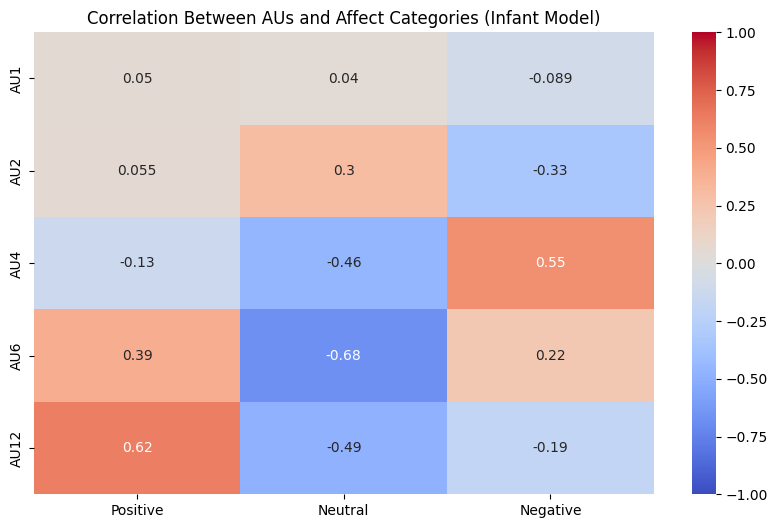

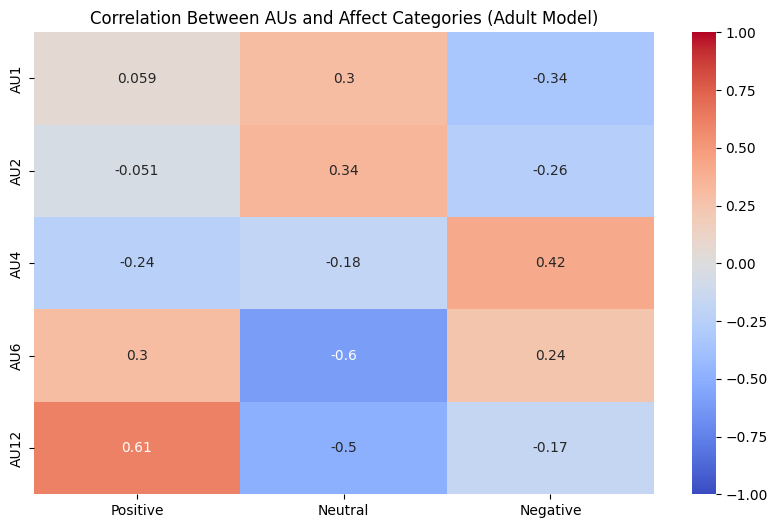

In [23]:
# Convert affect to binary labels for both datasets
pyafar_inf_df['Pos_label'] = (pyafar_inf_df['imageCat'] == 3).astype(int)
pyafar_inf_df['Neu_label'] = (pyafar_inf_df['imageCat'] == 2).astype(int)
pyafar_inf_df['Neg_label'] = (pyafar_inf_df['imageCat'] == 1).astype(int)

pyafar_adu_df['Pos_label'] = (pyafar_adu_df['imageCat'] == 3).astype(int)
pyafar_adu_df['Neu_label'] = (pyafar_adu_df['imageCat'] == 2).astype(int)
pyafar_adu_df['Neg_label'] = (pyafar_adu_df['imageCat'] == 1).astype(int)

# Define common AU columns
common_au_columns = ['AU1', 'AU2', 'AU4', 'AU6', 'AU12']

# For Infant dataset - calculate correlations between AUs and affect labels separately
inf_corr_pos = pyafar_inf_df[common_au_columns].corrwith(pyafar_inf_df['Pos_label'])
inf_corr_neu = pyafar_inf_df[common_au_columns].corrwith(pyafar_inf_df['Neu_label'])
inf_corr_neg = pyafar_inf_df[common_au_columns].corrwith(pyafar_inf_df['Neg_label'])

# For Adult dataset - calculate correlations between AUs and affect labels separately
adu_corr_pos = pyafar_adu_df[common_au_columns].corrwith(pyafar_adu_df['Pos_label'])
adu_corr_neu = pyafar_adu_df[common_au_columns].corrwith(pyafar_adu_df['Neu_label'])
adu_corr_neg = pyafar_adu_df[common_au_columns].corrwith(pyafar_adu_df['Neg_label'])

# Combine results into a DataFrame for visualization
corr_df_inf = pd.DataFrame({
    'Positive': inf_corr_pos,
    'Neutral': inf_corr_neu,
    'Negative': inf_corr_neg
})

corr_df_adu = pd.DataFrame({
    'Positive': adu_corr_pos,
    'Neutral': adu_corr_neu,
    'Negative': adu_corr_neg
})

# Plot for Infant dataset
plt.figure(figsize=(10, 6))
sns.heatmap(corr_df_inf, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Between AUs and Affect Categories (Infant Model)")
plt.show()

# Plot for Adult dataset
plt.figure(figsize=(10, 6))
sns.heatmap(corr_df_adu, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Between AUs and Affect Categories (Adult Model)")
plt.show()


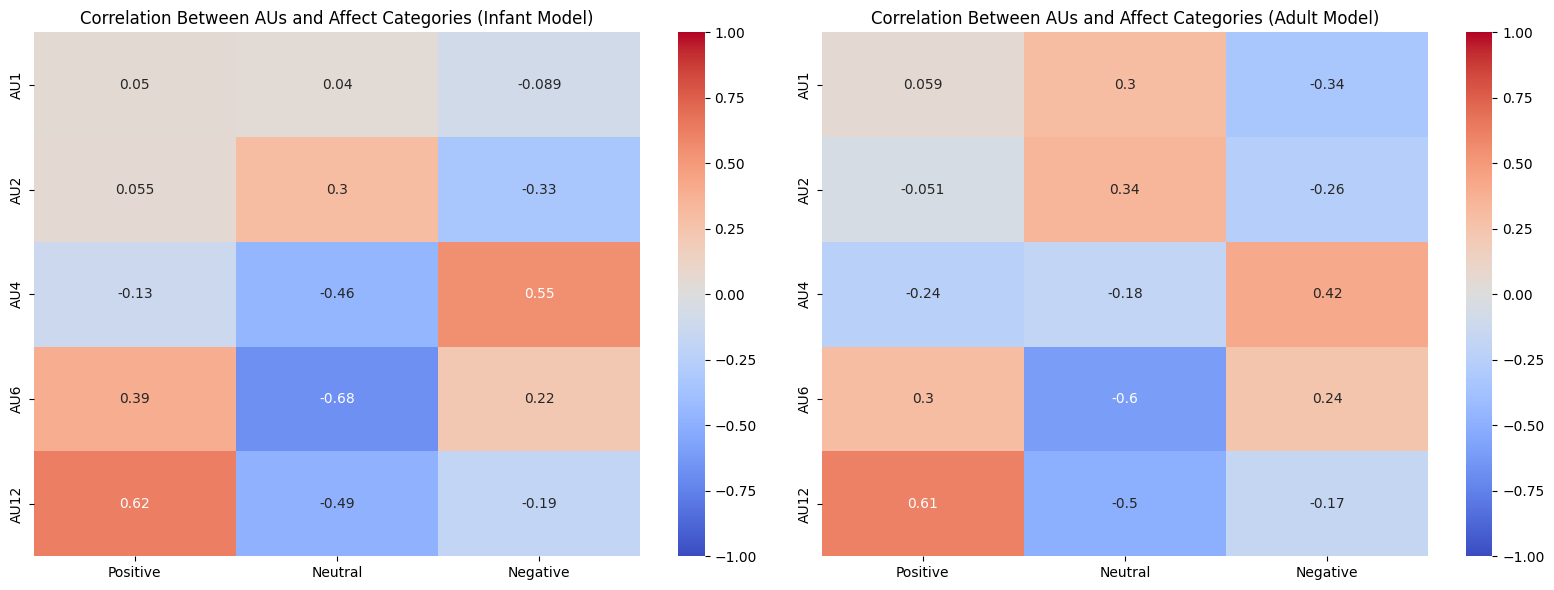

In [25]:
# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Infant dataset
sns.heatmap(corr_df_inf, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Correlation Between AUs and Affect Categories (Infant Model)")

# Plot for Adult dataset
sns.heatmap(corr_df_adu, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlation Between AUs and Affect Categories (Adult Model)")

# Adjust layout
plt.tight_layout()
plt.show()
